In [ ]:
# NOTHING OS — Notebook Styling
from IPython.display import HTML, display

display(HTML('''
<style>
  @import url('https://fonts.googleapis.com/css2?family=Share+Tech+Mono&family=Space+Mono&display=swap');

  :root {
    --nothing-black:   #0A0A0A;
    --nothing-surface: #111111;
    --nothing-border:  #2A2A2A;
    --nothing-white:   #F5F5F5;
    --nothing-gray-1:  #CCCCCC;
    --nothing-gray-2:  #888888;
    --nothing-gray-3:  #555555;
    --nothing-red:     #FF1C1C;
    --font-ndot:       'Share Tech Mono', monospace;
    --font-body:       'Space Mono', monospace;
  }

  body, .jp-Notebook {
    background: var(--nothing-black) !important;
    font-family: var(--font-body) !important;
  }

  .jp-Cell { border-radius: 0 !important; }

  .jp-InputArea-editor, .jp-CodeCell .jp-Editor {
    background: var(--nothing-surface) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-OutputArea-output {
    background: #0D0D0D !important;
    border-left: 2px solid var(--nothing-border) !important;
    font-family: var(--font-body) !important;
    color: var(--nothing-gray-1) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput h1, .jp-MarkdownOutput h2, .jp-MarkdownOutput h3 {
    font-family: var(--font-ndot) !important;
    color: var(--nothing-white) !important;
    letter-spacing: 0.1em;
    text-transform: uppercase;
    border-bottom: 1px solid var(--nothing-border) !important;
    padding-bottom: 8px;
  }

  .jp-MarkdownOutput h1 { font-size: 22px !important; }
  .jp-MarkdownOutput h2 { font-size: 16px !important; }
  .jp-MarkdownOutput h3 { font-size: 13px !important; color: var(--nothing-gray-2) !important; }

  .jp-MarkdownOutput p, .jp-MarkdownOutput li {
    color: var(--nothing-gray-2) !important;
    font-family: var(--font-body) !important;
    font-size: 12px !important;
  }

  .jp-MarkdownOutput code {
    background: var(--nothing-surface) !important;
    color: var(--nothing-red) !important;
    border: 1px solid var(--nothing-border) !important;
    border-radius: 0 !important;
    padding: 1px 5px;
    font-size: 11px !important;
  }

  .jp-Toolbar {
    background: #070707 !important;
    border-bottom: 1px solid var(--nothing-border) !important;
  }
</style>
'''))

# And configure matplotlib globally:
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor': '#0A0A0A', 'axes.facecolor': '#111111',
    'axes.edgecolor': '#2A2A2A', 'axes.labelcolor': '#888888',
    'text.color': '#888888', 'xtick.color': '#555555', 'ytick.color': '#555555',
    'grid.color': '#2A2A2A', 'grid.linewidth': 0.5, 'grid.linestyle': ':',
    'axes.grid': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'monospace', 'figure.titlesize': 11,
    'legend.facecolor': '#111111', 'legend.edgecolor': '#2A2A2A',
    'lines.linewidth': 1.5, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'axes.titlecolor': '#F5F5F5',
})

NOTHING_RED    = '#FF1C1C'
NOTHING_WHITE  = '#F5F5F5'
NOTHING_GRAY   = '#888888'
NOTHING_DIM    = '#555555'
NOTHING_MUTED  = '#3A3A3A'


# M5 Forecasting - Exploratory Data Analysis (EDA)
This notebook provides a comprehensive analysis of the M5 Forecasting dataset (Walmart sales).

**Objective:**
- Understand sales patterns
- Analyze pricing and promotions
- Assess impact of external events (holidays, SNAP)
- Prepare insights for Temporal Fusion Transformer (TFT) modeling

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import logging

# Add src to path
sys.path.append(os.path.abspath('../'))
from src.data.loader import M5Loader

# Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('../logs/eda', exist_ok=True)

loader = M5Loader(data_dir='../data')
calendar, sales, prices = loader.load_all()

INFO:src.data.loader:Loading all M5 datasets...
INFO:src.data.loader:Loading calendar data...
INFO:src.data.loader:Loading sales data...
INFO:src.data.loader:Loading prices data...


## 1. Dataset Statistics

In [2]:
print(f"Calendar shape: {calendar.shape}")
print(f"Sales shape: {sales.shape}")
print(f"Prices shape: {prices.shape}")

date_range = pd.to_datetime(calendar['date'])
print(f"Date range: {date_range.min().date()} to {date_range.max().date()}")
print(f"Total days: {calendar['d'].nunique()}")

print("\nUnique counts:")
print(f"Items: {sales['item_id'].nunique()}")
print(f"Stores: {sales['store_id'].nunique()}")
print(f"Categories: {sales['cat_id'].nunique()}")
print(f"Departments: {sales['dept_id'].nunique()}")

print("\nState distribution:")
print(sales['state_id'].value_counts())

Calendar shape: (1969, 14)
Sales shape: (30490, 1947)
Prices shape: (6841121, 4)
Date range: 2011-01-29 to 2016-06-19
Total days: 1969

Unique counts:
Items: 3049
Stores: 10
Categories: 3
Departments: 7

State distribution:
state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64


## 2. Sales Distribution Analysis

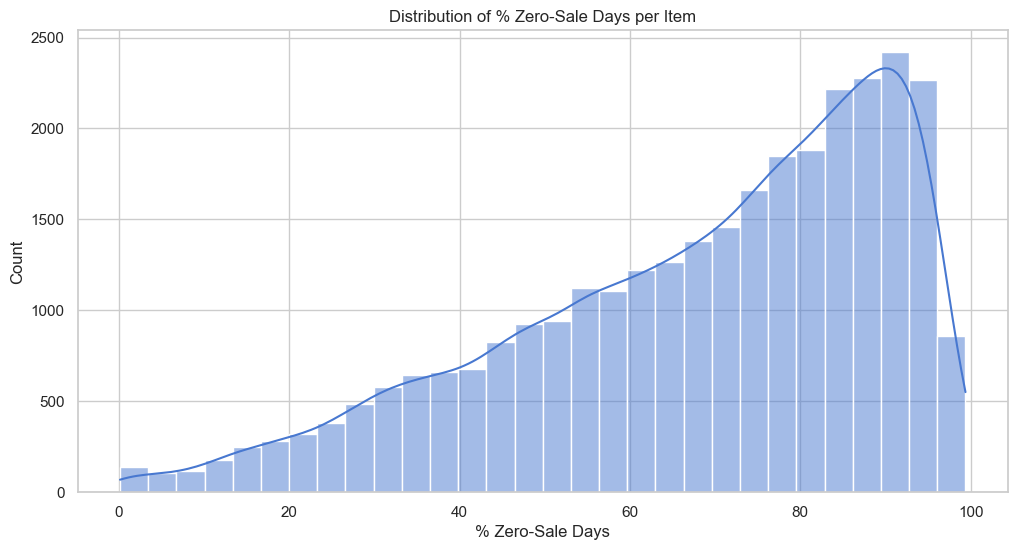

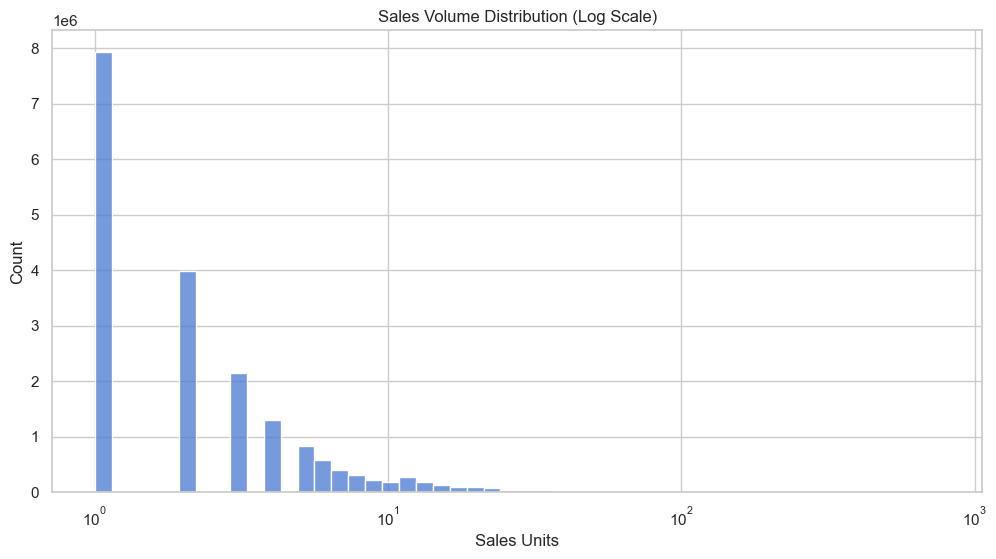

Top 5 Selling Items:
                                id  total_sales
8412   FOODS_3_090_CA_3_evaluation       253859
18055  FOODS_3_586_TX_2_evaluation       195120
21104  FOODS_3_586_TX_3_evaluation       151862
8908   FOODS_3_586_CA_3_evaluation       136269
2314   FOODS_3_090_CA_1_evaluation       128855


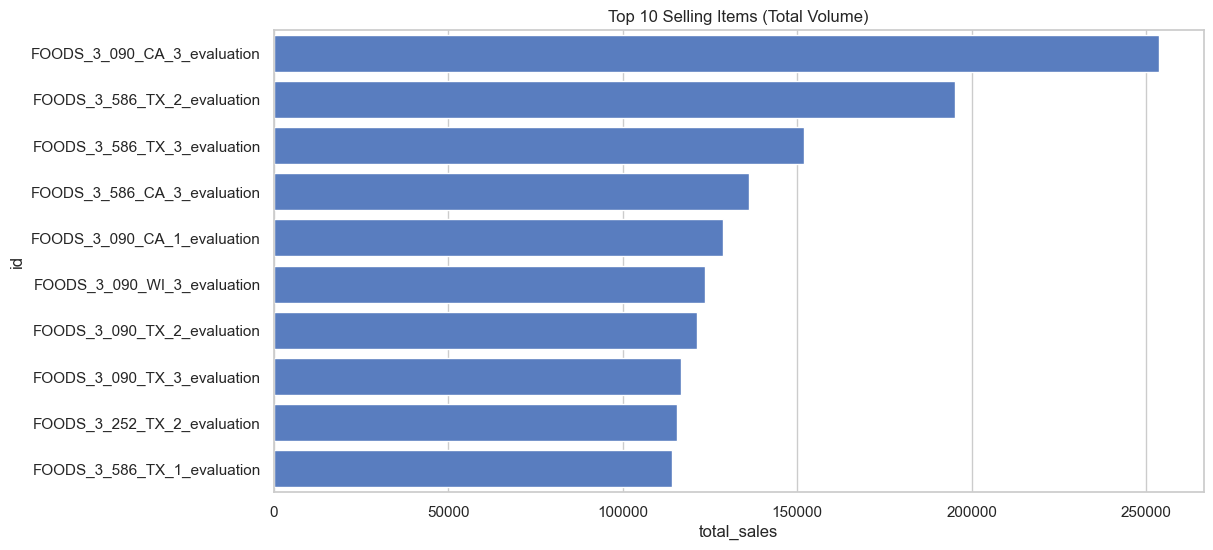

In [3]:
# % zero-sale days per item
d_cols = [c for c in sales.columns if c.startswith('d_')]
zero_sales_pct = (sales[d_cols] == 0).mean(axis=1) * 100

plt.figure()
sns.histplot(zero_sales_pct, kde=True, bins=30)
plt.title("Distribution of % Zero-Sale Days per Item")
plt.xlabel("% Zero-Sale Days")
plt.savefig('../logs/eda/zero_sales_dist.png')
plt.show()

# Sales distribution (log scale)
all_sales = sales[d_cols].values.flatten()
all_sales = all_sales[all_sales > 0] # exclude zeros for log scale

plt.figure()
sns.histplot(all_sales, bins=50, log_scale=True)
plt.title("Sales Volume Distribution (Log Scale)")
plt.xlabel("Sales Units")
plt.savefig('../logs/eda/sales_volume_log.png')
plt.show()

# Top/Bottom selling items
sales['total_sales'] = sales[d_cols].sum(axis=1)
top_items = sales.sort_values('total_sales', ascending=False).head(10)
bottom_items = sales.sort_values('total_sales', ascending=True).head(10)

print("Top 5 Selling Items:")
print(top_items[['id', 'total_sales']].head())

plt.figure()
sns.barplot(data=top_items, x='total_sales', y='id')
plt.title("Top 10 Selling Items (Total Volume)")
plt.savefig('../logs/eda/top_items.png')
plt.show()

## 3. Time Series Visualization

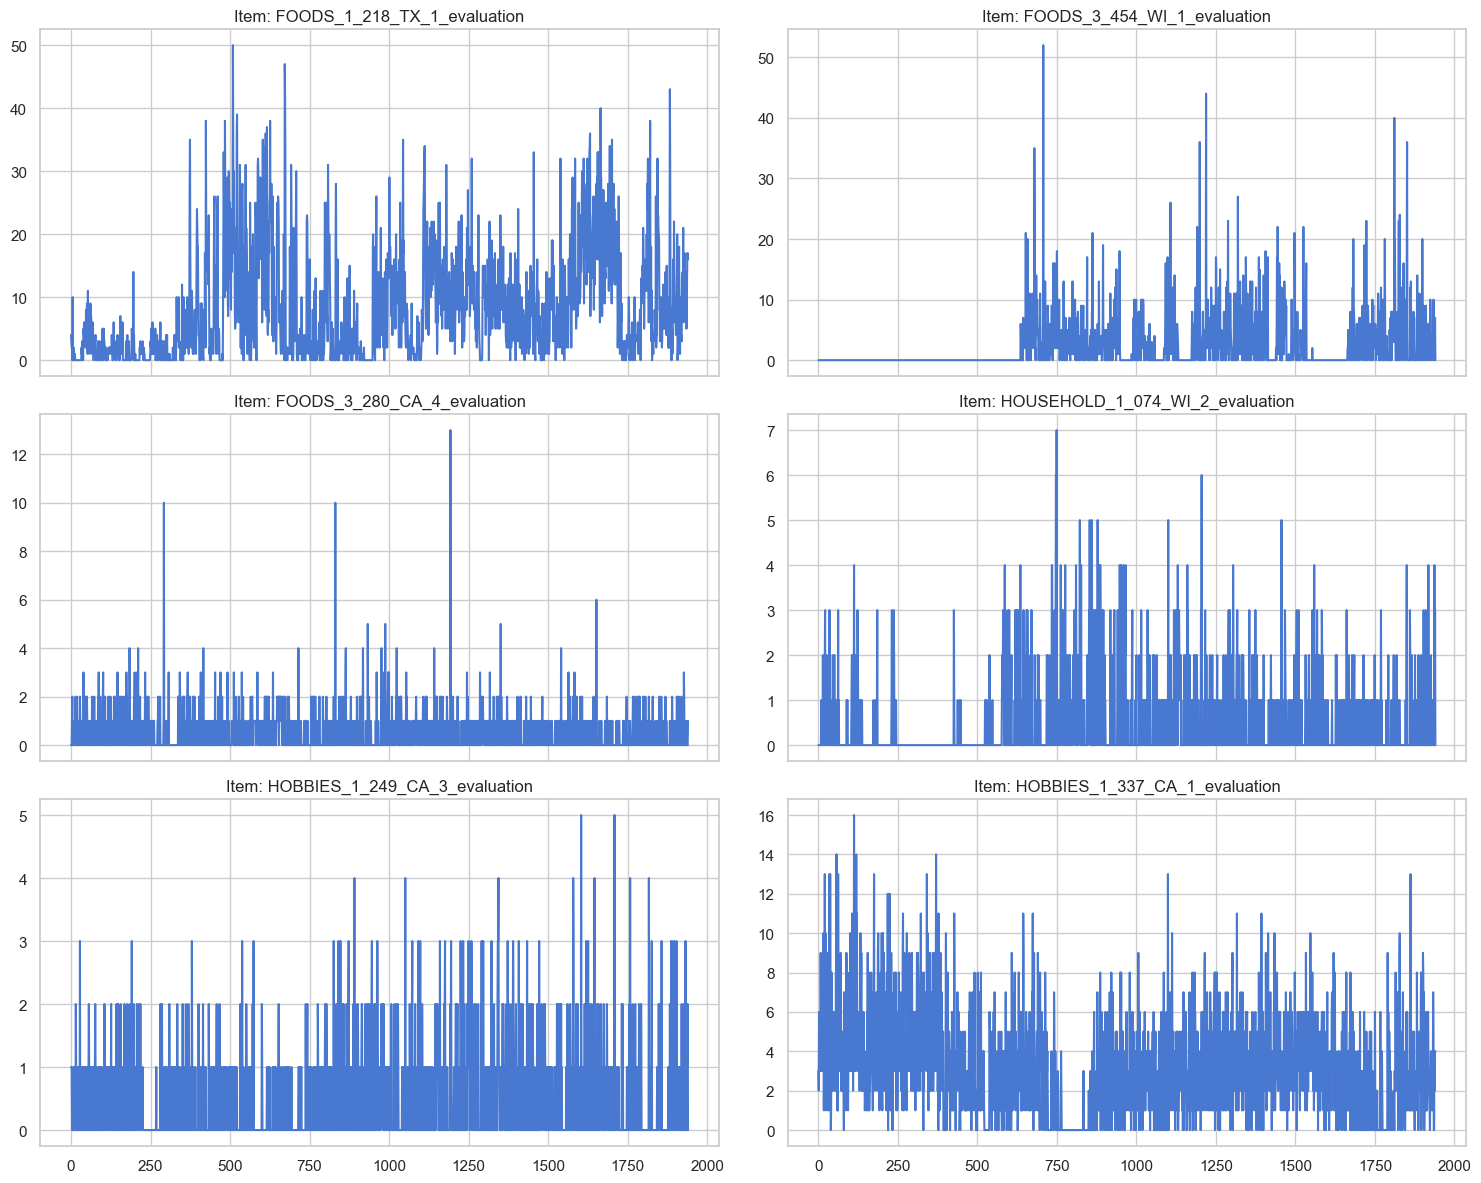

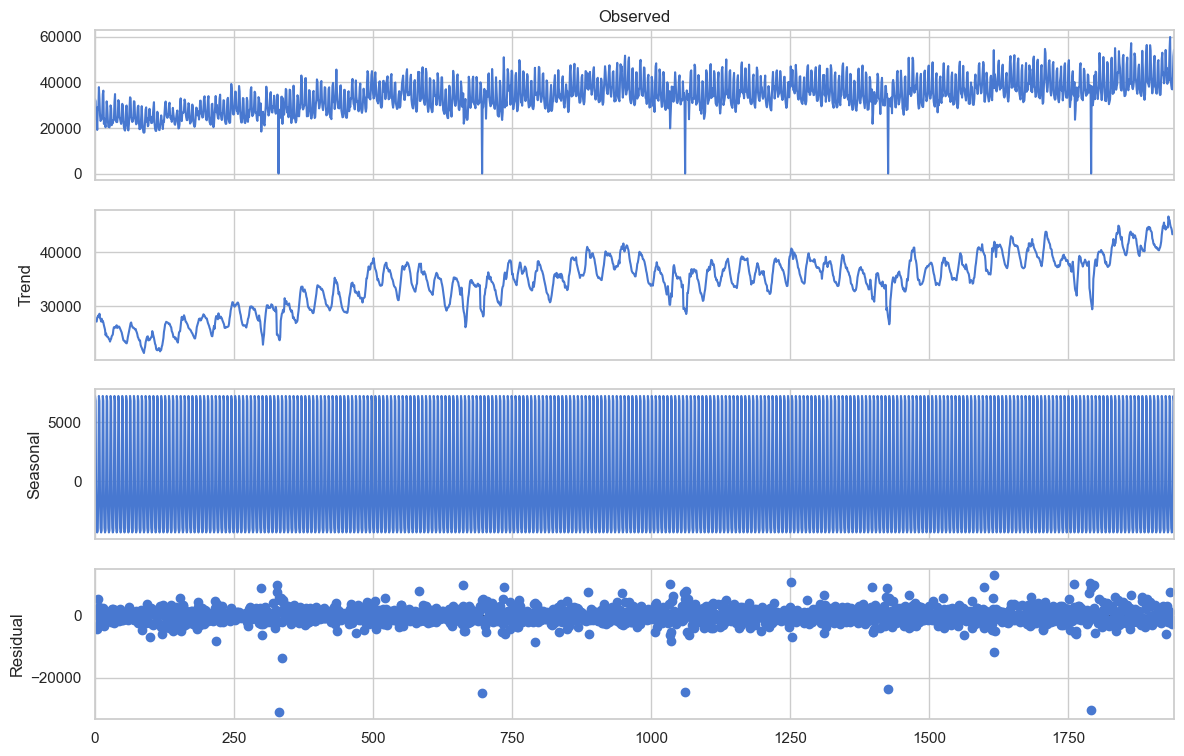

In [4]:
# Plot 6 random items
random_indices = np.random.choice(sales.index, 6, replace=False)
fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    item_sales = sales.loc[idx, d_cols].values
    axes[i].plot(item_sales)
    axes[i].set_title(f"Item: {sales.loc[idx, 'id']}")

plt.tight_layout()
plt.savefig('../logs/eda/random_items_ts.png')
plt.show()

# Seasonality Decomposition (Aggregate Sales)
total_daily_sales = sales[d_cols].sum(axis=0).values
decomp = seasonal_decompose(total_daily_sales, period=7) # Weekly seasonality

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.savefig('../logs/eda/seasonality_decomp.png')
plt.show()

## 4. Price Analysis

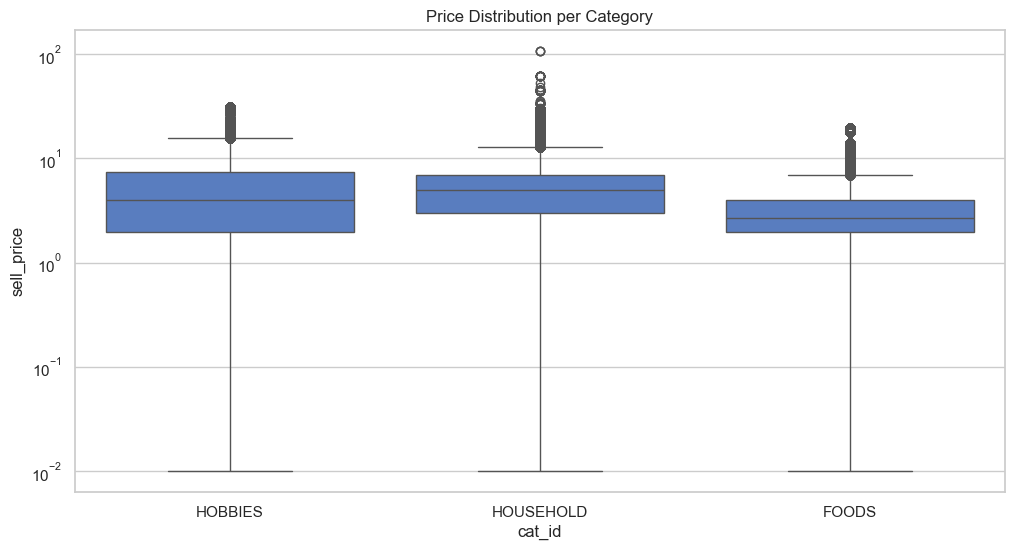

INFO:src.data.loader:Loading merged sample of 1 items...
INFO:src.data.loader:Loading sales data...


Average weekly promotion frequency (price drop > 5%): 0.37%


INFO:src.data.loader:Loading calendar data...
INFO:src.data.loader:Loading prices data...


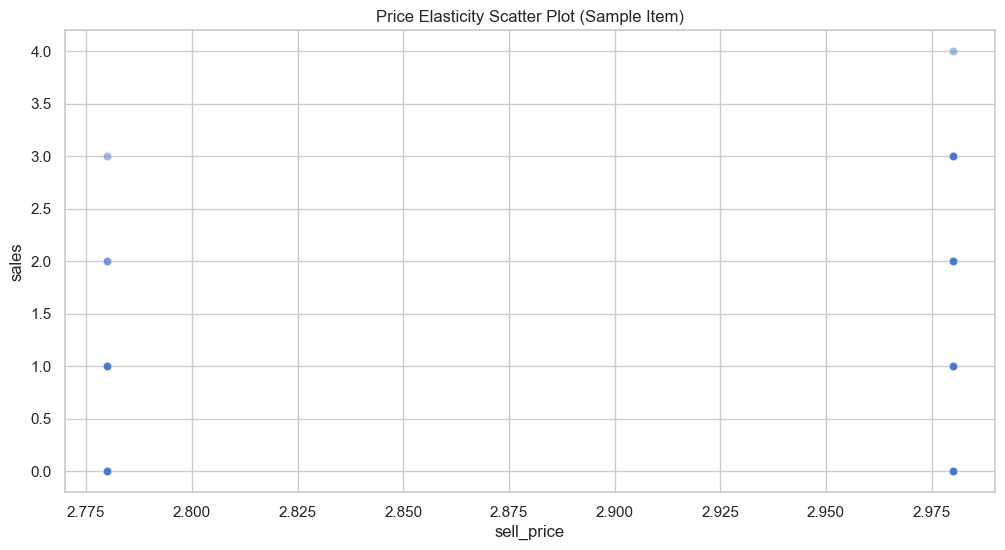

In [5]:
# Price distribution per category
# Need to merge prices with item categories
item_cats = sales[['item_id', 'cat_id']].drop_duplicates()
price_analysis = prices.merge(item_cats, on='item_id', how='left')

plt.figure()
sns.boxplot(data=price_analysis, x='cat_id', y='sell_price')
plt.title("Price Distribution per Category")
plt.yscale('log')
plt.savefig('../logs/eda/price_dist_cat.png')
plt.show()

# Promotion Frequency (Price Drops > 5% week-over-week)
price_analysis = price_analysis.sort_values(['store_id', 'item_id', 'wm_yr_wk'])
price_analysis['prev_price'] = price_analysis.groupby(['store_id', 'item_id'])['sell_price'].shift(1)
price_analysis['price_change'] = (price_analysis['sell_price'] - price_analysis['prev_price']) / price_analysis['prev_price']
promo_freq = (price_analysis['price_change'] < -0.05).mean() * 100
print(f"Average weekly promotion frequency (price drop > 5%): {promo_freq:.2f}%")

# Price Elasticity (Sample for top item)
top_item_id = top_items.iloc[0]['item_id']
top_store_id = top_items.iloc[0]['store_id']
item_data = loader.load_merged_sample(n_items=1)
# In a real scenario, we'd use the specific top item

plt.figure()
sns.scatterplot(data=item_data, x='sell_price', y='sales', alpha=0.5)
plt.title(f"Price Elasticity Scatter Plot (Sample Item)")
plt.savefig('../logs/eda/price_elasticity.png')
plt.show()

## 5. Event and SNAP Impact

INFO:src.data.loader:Loading merged sample of 500 items...
INFO:src.data.loader:Loading sales data...
INFO:src.data.loader:Loading calendar data...
INFO:src.data.loader:Loading prices data...


Avg Sales - Non-Event: 0.96, Event: 0.92
Sales Lift: -3.64%


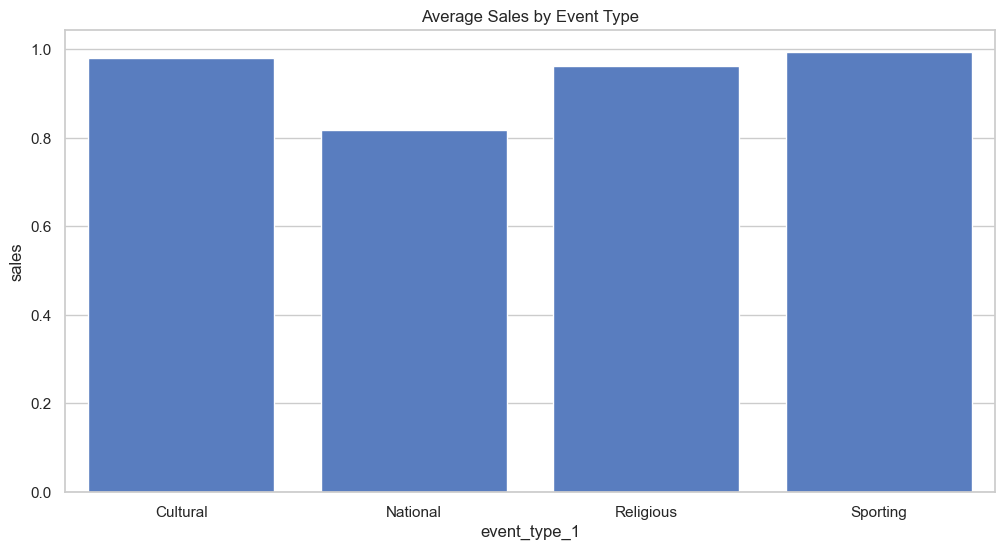


SNAP Uplift by State:
  State   No SNAP      SNAP   Uplift %
0    CA  1.151535  1.213550   5.385422
1    TX  0.749953  0.865167  15.362796
2    WI  0.789609  0.956505  21.136470


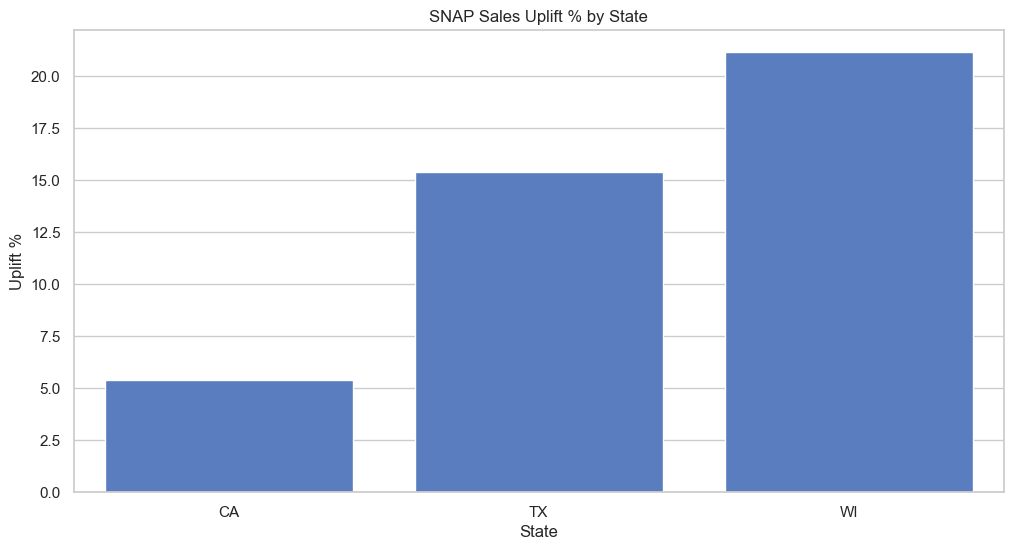

In [6]:
# Load a larger sample for impact analysis
sample_df = loader.load_merged_sample(n_items=500)

# Sales lift on event days
sample_df['has_event'] = sample_df['event_name_1'].notna()
lift = sample_df.groupby('has_event')['sales'].mean()
print(f"Avg Sales - Non-Event: {lift[False]:.2f}, Event: {lift[True]:.2f}")
print(f"Sales Lift: {(lift[True]/lift[False] - 1)*100:.2f}%")

# Heatmap of sales by event type
event_type_sales = sample_df[sample_df['event_type_1'].notna()].groupby('event_type_1')['sales'].mean().reset_index()
plt.figure()
sns.barplot(data=event_type_sales, x='event_type_1', y='sales')
plt.title("Average Sales by Event Type")
plt.savefig('../logs/eda/event_type_impact.png')
plt.show()

# SNAP Analysis
snap_cols = ['snap_CA', 'snap_TX', 'snap_WI']
snap_results = []
for state in ['CA', 'TX', 'WI']:
    state_df = sample_df[sample_df['state_id'] == state]
    snap_col = f'snap_{state}'
    snap_lift = state_df.groupby(snap_col)['sales'].mean()
    snap_results.append({'State': state, 'No SNAP': snap_lift[0], 'SNAP': snap_lift[1], 'Uplift %': (snap_lift[1]/snap_lift[0]-1)*100})

snap_summary = pd.DataFrame(snap_results)
print("\nSNAP Uplift by State:")
print(snap_summary)
plt.figure()
sns.barplot(data=snap_summary, x='State', y='Uplift %')
plt.title("SNAP Sales Uplift % by State")
plt.savefig('../logs/eda/snap_uplift.png')
plt.show()

## 6. Correlation Analysis

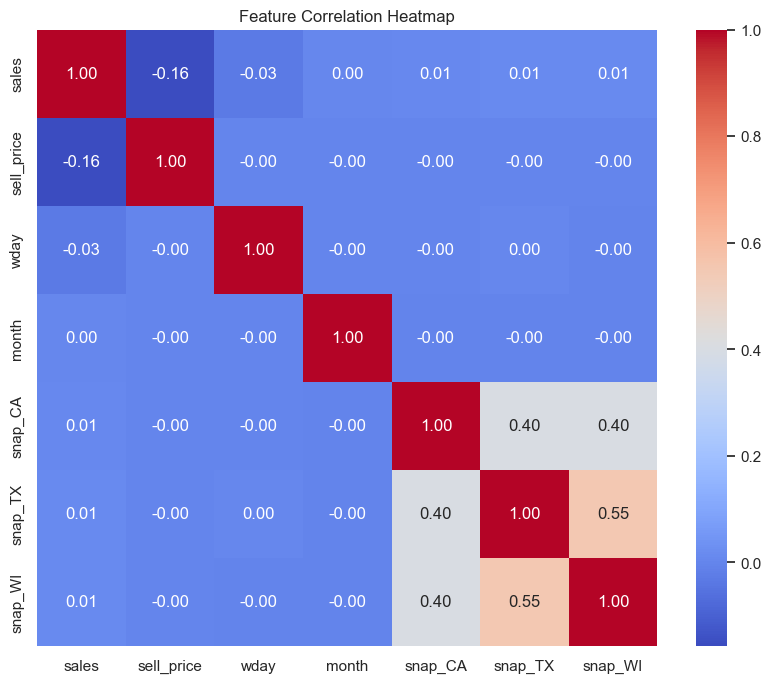

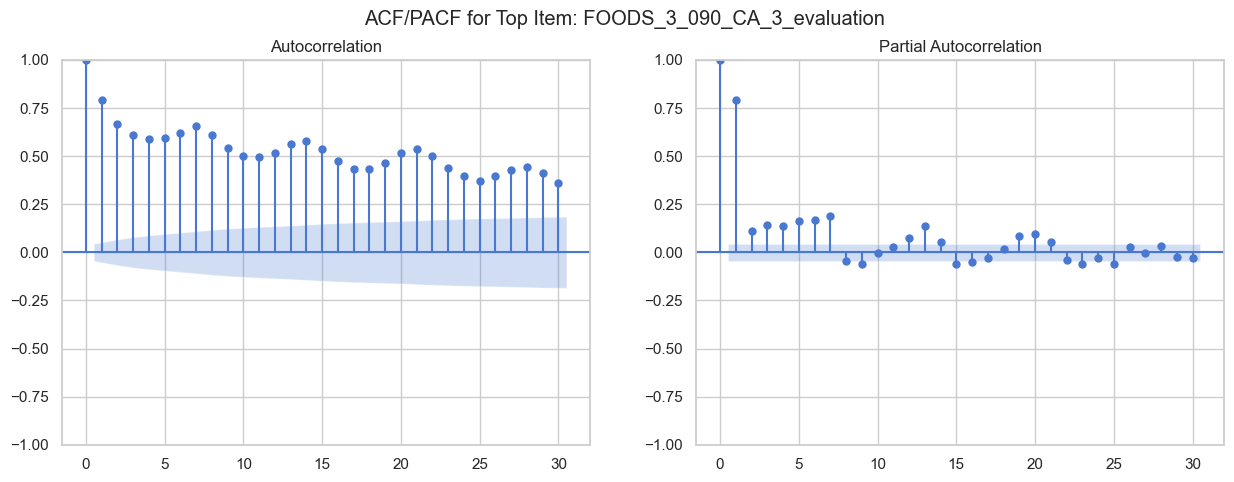

In [7]:
# Feature correlation heatmap
corr_cols = ['sales', 'sell_price', 'wday', 'month', 'snap_CA', 'snap_TX', 'snap_WI']
plt.figure(figsize=(10, 8))
sns.heatmap(sample_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.savefig('../logs/eda/corr_heatmap.png')
plt.show()

# Lag Autocorrelation (ACF/PACF) for top items
top_ts = sales.loc[sales['total_sales'].idxmax(), d_cols].values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(top_ts, lags=30, ax=ax1)
plot_pacf(top_ts, lags=30, ax=ax2)
plt.suptitle(f"ACF/PACF for Top Item: {sales.loc[sales['total_sales'].idxmax(), 'id']}")
plt.savefig('../logs/eda/acf_pacf.png')
plt.show()